# Quantitative Risk Management - An Application of Machine Learning

### Import required libraries

In [1]:
# Helper function to install and import packages
def install_and_import(pip_name, import_name=None, alias=None):
    """
    pip_name:     name to install via pip
    import_name:  actual Python module to import
    alias:        optional alias
    """
    import importlib
    import_name = import_name or pip_name
    try:
        module = importlib.import_module(import_name)
    except ImportError:
        import subprocess
        import sys
        print(f"Installing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        module = importlib.import_module(import_name)
    
    # Set alias or module name in global scope
    if alias:
        globals()[alias] = module
    else:
        globals()[import_name] = module

In [2]:
# Use the function to import required packages
install_and_import("pandas", "pandas", "pd")
install_and_import("kagglehub")
import os

c:\Users\FED\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Download the Lending Club dataset from Kaggle

In [3]:
def load_lending_club_accepted():
    # Define target subfolder and filename
    expected_dir = os.path.expanduser("~/.cache/kagglehub/datasets/wordsforthewise/lending-club")
    expected_csv = "accepted_2007_to_2018Q4.csv"

    # Try to find the file by walking through subfolders
    for root, _, files in os.walk(expected_dir):
        if expected_csv in files:
            print("Found dataset locally.")
            return pd.read_csv(os.path.join(root, expected_csv), low_memory=False)

    # If not found, download it
    print("Dataset not found. Downloading from Kaggle...")
    path = kagglehub.dataset_download("wordsforthewise/lending-club")
    
    # Try to locate the CSV
    for root, _, files in os.walk(path):
        if expected_csv in files:
            print("Dataset downloaded and located.")
            return pd.read_csv(os.path.join(root, expected_csv), low_memory=False)

    raise FileNotFoundError("Could not locate 'accepted_2007_to_2018Q4.csv' after download.")

In [4]:
loans_raw = load_lending_club_accepted()
print("Loaded dataset shape:", loans_raw.shape)

Found dataset locally.
Loaded dataset shape: (2260701, 151)


In [5]:
pd.set_option('display.max_columns', None)
display(loans_raw.head(10))

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

### Preview structure

In [6]:
print("Shape:", loans_raw.shape)
print("\nColumn types:")
for col, dtype in loans_raw.dtypes.items():
    print(f"{col:<30} {dtype}")

Shape: (2260701, 151)

Column types:
id                             object
member_id                      float64
loan_amnt                      float64
funded_amnt                    float64
funded_amnt_inv                float64
term                           object
int_rate                       float64
installment                    float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                     float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
desc                           object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                            float64
delin

### Subset the dataframe

In [ ]:
# define columns I want to keep
final_columns = [
    "addr_state", "annual_inc", "application_type", "dti", "emp_length", 
    "fico_range_high", "fico_range_low", "home_ownership", "id", "issue_d", 
    "loan_amnt", "loan_status", "purpose", "pymnt_plan", "term", "int_rate",
    "verification_status", "annual_inc_joint", "dti_joint", "member_id",
    "verification_status_joint", "disbursement_method", "funded_amnt", "installment",
]

# subset and inspect structre again
loans_raw = loans_raw[final_columns]

# Convert 'issue_d' to datetime
loans_raw["issue_d"] = pd.to_datetime(loans_raw["issue_d"], format="%b-%Y", errors="coerce")

# Convert 'id' to string in case it's read as object
loans_raw["id"] = loans_raw["id"].astype(str)

# Convert emp_length to string (cleaning content later)
loans_raw["emp_length"] = loans_raw["emp_length"].astype(str)
loans_raw["emp_length"] = loans_raw["emp_length"].replace("nan", None)


print("Final subset shape:", loans_raw.shape)
print("\nColumn types after type conversion:")
for col, dtype in loans_raw.dtypes.items():
    print(f"{col:<30} {dtype}")

Final subset shape: (2260701, 24)

Column types after type conversion:
addr_state                     object
annual_inc                     float64
application_type               object
dti                            float64
emp_length                     object
fico_range_high                float64
fico_range_low                 float64
home_ownership                 object
id                             object
issue_d                        datetime64[ns]
loan_amnt                      float64
loan_status                    object
purpose                        object
pymnt_plan                     object
term                           object
int_rate                       float64
verification_status            object
annual_inc_joint               float64
dti_joint                      float64
member_id                      float64
verification_status_joint      object
disbursement_method            object
funded_amnt                    float64
installment                    float6

### Display unique values for each categorical/object column

In [8]:
print("\nUnique values per categorical column:")
for col in loans_raw.select_dtypes(include='object').columns:
    if col == "id":   
        continue
    print(f"\n--- {col} ---")
    print(loans_raw[col].unique())


Unique values per categorical column:

--- addr_state ---
['PA' 'SD' 'IL' 'NJ' 'GA' 'MN' 'SC' 'RI' 'TX' 'NC' 'CA' 'VA' 'AZ' 'NY'
 'IN' 'MD' 'KS' 'NM' 'AL' 'WA' 'MO' 'OH' 'LA' 'FL' 'CO' 'MI' 'TN' 'DC'
 'MA' 'WI' 'HI' 'VT' 'DE' 'NH' 'NE' 'CT' 'OR' 'AR' 'MT' 'NV' 'WV' 'WY'
 'OK' 'KY' 'MS' 'ME' 'UT' 'ND' 'AK' nan 'ID' 'IA']

--- application_type ---
['Individual' 'Joint App' nan]

--- emp_length ---
['10+ years' '3 years' '4 years' '6 years' '1 year' '7 years' '8 years'
 '5 years' '2 years' '9 years' '< 1 year' None]

--- home_ownership ---
['MORTGAGE' 'RENT' 'OWN' 'ANY' nan 'NONE' 'OTHER']

--- loan_status ---
['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']

--- purpose ---
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'r

### Check for null values in each column

In [9]:
print("\nPercentage of missing values per column:")
for col in loans_raw.columns:
    missing_percentage = loans_raw[col].isnull().mean() * 100
    print(f"{col:<30} {missing_percentage:.2f}%")


Percentage of missing values per column:
addr_state                     0.00%
annual_inc                     0.00%
application_type               0.00%
dti                            0.08%
emp_length                     6.50%
fico_range_high                0.00%
fico_range_low                 0.00%
home_ownership                 0.00%
id                             0.00%
issue_d                        0.00%
loan_amnt                      0.00%
loan_status                    0.00%
purpose                        0.00%
pymnt_plan                     0.00%
term                           0.00%
int_rate                       0.00%
verification_status            0.00%
annual_inc_joint               94.66%
dti_joint                      94.66%
member_id                      100.00%
verification_status_joint      94.88%
disbursement_method            0.00%
funded_amnt                    0.00%
installment                    0.00%


### Create final_annual_income, final_dti, final_verification_status

In [10]:
loans_raw["final_annual_income"] = loans_raw.apply(
    lambda row: row["annual_inc_joint"] if row["application_type"] == "Joint App" else row["annual_inc"],
    axis=1
)

loans_raw["final_dti"] = loans_raw.apply(
    lambda row: row["dti_joint"] if row["application_type"] == "Joint App" else row["dti"],
    axis=1
)

loans_raw["final_verification_status"] = loans_raw.apply(
    lambda row: row["verification_status_joint"] if row["application_type"] == "Joint App" else row["verification_status"],
    axis=1
)

### Drop the old columns

In [11]:
cols_to_drop = [
    "annual_inc", "annual_inc_joint",
    "dti", "dti_joint",
    "verification_status", "verification_status_joint"
]

loans_raw.drop(columns=cols_to_drop, inplace=True)

### Display percentage of distribution of some categorical variables (application_type, pymnt_plan, term, verification_status, verification_status_joint, disbursement_method)

In [12]:
categorical_cols = [
    "application_type", "pymnt_plan", "term", 
    "final_verification_status", "disbursement_method"
]

for col in categorical_cols:
    print(f"\n--- {col} distribution ---")
    print(loans_raw[col].value_counts(normalize=True) * 100)


--- application_type distribution ---
application_type
Individual    94.660428
Joint App      5.339572
Name: proportion, dtype: float64

--- pymnt_plan distribution ---
pymnt_plan
n    99.972574
y     0.027426
Name: proportion, dtype: float64

--- term distribution ---
term
36 months    71.207006
60 months    28.792994
Name: proportion, dtype: float64

--- final_verification_status distribution ---
final_verification_status
Source Verified    39.312263
Not Verified       33.586427
Verified           27.101310
Name: proportion, dtype: float64

--- disbursement_method distribution ---
disbursement_method
Cash         96.544296
DirectPay     3.455704
Name: proportion, dtype: float64


### Check again the percentage of null values in each column

In [ ]:
print("\nPercentage of missing values per column:")
for col in loans_raw.columns:
    missing_percentage = loans_raw[col].isnull().mean() * 100
    print(f"{col:<30} {missing_percentage:.2f}%")


Percentage of missing values per column:
addr_state                     0.00%
application_type               0.00%
emp_length                     6.50%
fico_range_high                0.00%
fico_range_low                 0.00%
home_ownership                 0.00%
id                             0.00%
issue_d                        0.00%
loan_amnt                      0.00%
loan_status                    0.00%
purpose                        0.00%
pymnt_plan                     0.00%
term                           0.00%
int_rate                       0.00%
member_id                      100.00%
disbursement_method            0.00%
funded_amnt                    0.00%
installment                    0.00%
final_annual_income            0.00%
final_dti                      0.00%
final_verification_status      0.22%


### Delete column member_id, pymnt_plan and drop all rows with null values

In [14]:
loans_raw.drop(columns=["pymnt_plan"], inplace=True)
loans_raw.drop(columns=["member_id"], inplace=True)
loans_cleaned = loans_raw.dropna().reset_index(drop=True)

### Display again the data

In [15]:
pd.set_option('display.max_columns', None)
display(loans_cleaned.head(10))

,addr_state,application_type,emp_length,fico_range_high,fico_range_low,home_ownership,id,issue_d,loan_amnt,loan_status,purpose,term,int_rate,disbursement_method,funded_amnt,installment,final_annual_income,final_dti,final_verification_status
0,PA,Individual,10+ years,679.0,675.0,MORTGAGE,68407277,2015-12-01,3600.0,Fully Paid,debt_consolidation,36 months,13.99,Cash,3600.0,123.03,55000.0,5.91,Not Verified
1,SD,Individual,10+ years,719.0,715.0,MORTGAGE,68355089,2015-12-01,24700.0,Fully Paid,small_business,36 months,11.99,Cash,24700.0,820.28,65000.0,16.06,Not Verified
2,IL,Joint App,10+ years,699.0,695.0,MORTGAGE,68341763,2015-12-01,20000.0,Fully Paid,home_improvement,60 months,10.78,Cash,20000.0,432.66,71000.0,13.85,Not Verified
3,NJ,Individual,10+ years,789.0,785.0,MORTGAGE,66310712,2015-12-01,35000.0,Current,debt_consolidation,60 months,14.85,Cash,35000.0,829.90,110000.0,17.06,Source Verified
4,PA,Individual,3 years,699.0,695.0,MORTGAGE,68476807,2015-12-01,10400.0,Fully Paid,major_purchase,60 months,22.45,Cash,10400.0,289.91,104433.0,25.37,Source Verified
5,GA,Individual,4 years,694.0,690.0,RENT,68426831,2015-12-01,11950.0,Fully Paid,debt_consolidation,36 months,13.44,Cash,11950.0,405.18,34000.0,10.20,Source Verified
6,MN,Individual,10+ years,684.0,680.0,MORTGAGE,68476668,2015-12-01,20000.0,Fully Paid,debt_consolidation,36 months,9.17,Cash,20000.0,637.58,180000.0,14.67,Not Verified
7,SC,Individual,10+ years,709.0,705.0,MORTGAGE,67275481,2015-12-01,20000.0,Fully Paid,major_purchase,36 months,8.49,Cash,20000.0,631.26,85000.0,17.61,Not Verified
8,PA,Individual,6 years,689.0,685.0,RENT,68466926,2015-12-01,10000.0,Fully Paid,credit_card,36 months,6.49,Cash,10000.0,306.45,85000.0,13.07,Not Verified
9,RI,Individual,10+ years,704.0,700.0,MORTGAGE,68616873,2015-12-01,8000.0,Fully Paid,credit_card,36 months,11.48,Cash,8000.0,263.74,42000.0,34.80,Not Verified


### Mapping for the target variable loan status

In [16]:
status_mapping = {
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Does not meet the credit policy. Status:Charged Off": 1
}

loans_cleaned = loans_cleaned[loans_cleaned["loan_status"].isin(status_mapping.keys())].copy()
loans_cleaned["target_loan_status"] = loans_cleaned["loan_status"].map(status_mapping)
loans_cleaned.drop(columns=["loan_status"], inplace=True)

### Mapping for the employment lenght

In [17]:
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5
}

loans_cleaned["emp_length_clean"] = loans_cleaned["emp_length"].map(emp_length_mapping)
# drop the original emp_length column
loans_cleaned.drop(columns=["emp_length"], inplace=True)

### Convert term to integer

In [18]:
loans_cleaned["term_clean"] = loans_cleaned["term"].str.extract(r'(\d+)').astype(int)
loans_cleaned.drop(columns=["term"], inplace=True)

### Create avergae FICO range

In [19]:
loans_cleaned["fico_range_avg"] = (loans_cleaned["fico_range_low"] + loans_cleaned["fico_range_high"]) / 2

### Check if it makes sense to create a flag for full amount funded

In [20]:
loans_cleaned["fully_funded_flag"] = (loans_cleaned["loan_amnt"] == loans_cleaned["funded_amnt"]).astype(int)

# check distrubtion percentage of fully_funded_flag
print("\n--- fully_funded_flag distribution ---")
print(loans_cleaned["fully_funded_flag"].value_counts(normalize=True) * 100)


--- fully_funded_flag distribution ---
fully_funded_flag
1    99.840472
0     0.159528
Name: proportion, dtype: float64


### Drop columns fully_funded_flag, funded_amnt

In [21]:
loans_cleaned.drop(columns=["fully_funded_flag", "funded_amnt"], inplace=True)

### Check percentages of variables in home_ownership column

In [22]:
print("\n--- home_ownership ---")
print(loans_cleaned["home_ownership"].value_counts(normalize=True) * 100)


--- home_ownership ---
home_ownership
MORTGAGE    49.663296
RENT        40.105927
OWN         10.191938
ANY          0.021034
OTHER        0.014102
NONE         0.003703
Name: proportion, dtype: float64


### Group rare categories like "ANY" and "NONE" into "OTHER"

In [23]:
# group rare categories lie ay and none into 'OTHER'
loans_cleaned["home_ownership_clean"] = loans_cleaned["home_ownership"].replace(
    {"ANY": "OTHER", "NONE": "OTHER", "OTHER": "OTHER"}
)

# drop home_ownership_clean
loans_cleaned.drop(columns=["home_ownership"], inplace=True)

### Final check for null values and shape

In [ ]:
### check count for null values again - absolute count
print("\nAbsolute count of missing values per column after cleaning:")
for col in loans_cleaned.columns:
    missing_count = loans_cleaned[col].isnull().sum()
    print(f"{col:<30} {missing_count}")

print("\nFinal loans_cleaned dataset shape:", loans_cleaned.shape)


Absolute count of missing values per column after cleaning:
addr_state                     0
application_type               0
fico_range_high                0
fico_range_low                 0
id                             0
issue_d                        0
loan_amnt                      0
purpose                        0
int_rate                       0
disbursement_method            0
installment                    0
final_annual_income            0
final_dti                      0
final_verification_status      0
target_loan_status             0
emp_length_clean               0
term_clean                     0
fico_range_avg                 0
home_ownership_clean           0

Final loans_cleaned dataset shape: (1269366, 19)


## EDA visualizations

In [25]:
# Imports
install_and_import("seaborn", "seaborn", "sns")
install_and_import("matplotlib", "matplotlib.pyplot", "plt")

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Target variable distribution

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\2223811667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


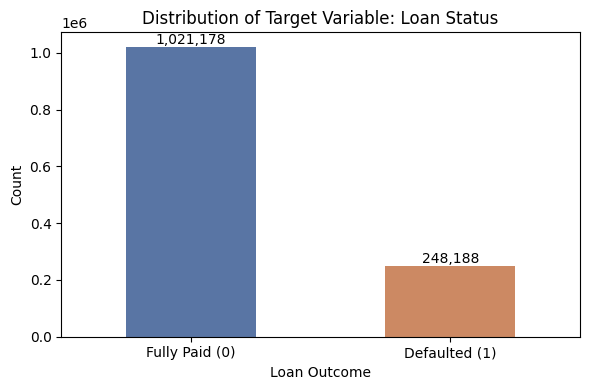

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x="target_loan_status",
    data=loans_cleaned,
    width=0.5,
    palette={"0": "#4C72B0", "1": "#DD8452"} # blue for 0, orange for 1
)
plt.title("Distribution of Target Variable: Loan Status")
plt.xticks([0, 1], ['Fully Paid (0)', 'Defaulted (1)'])
plt.xlabel("Loan Outcome")
plt.ylabel("Count")

# labels
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 2. Employment lenght distribution

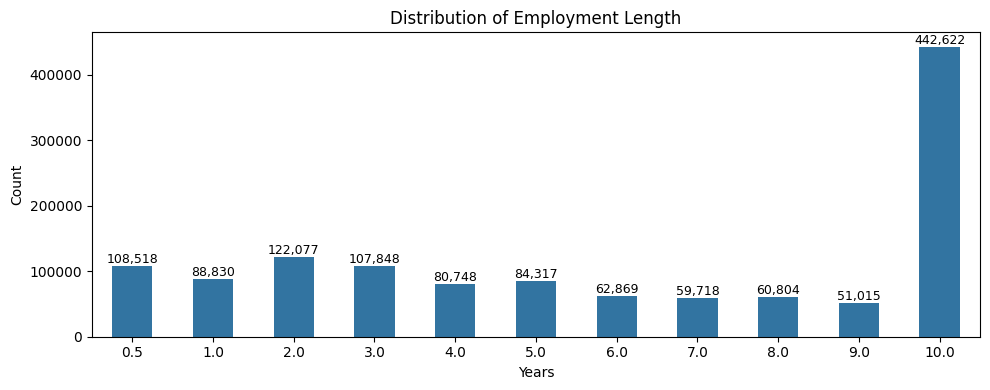

In [29]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(x="emp_length_clean", data=loans_cleaned, width=0.5, order=sorted(loans_cleaned["emp_length_clean"].unique()))
plt.title("Distribution of Employment Length")
plt.xlabel("Years")
plt.ylabel("Count")

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 3. Term distribution (36 or 60 month)

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\913311001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="term_clean", data=loans_cleaned, width=0.5, palette=["#4C72B0"])  # blue
C:\Users\FED\AppData\Local\Temp\ipykernel_27828\913311001.py:2: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(x="term_clean", data=loans_cleaned, width=0.5, palette=["#4C72B0"])  # blue


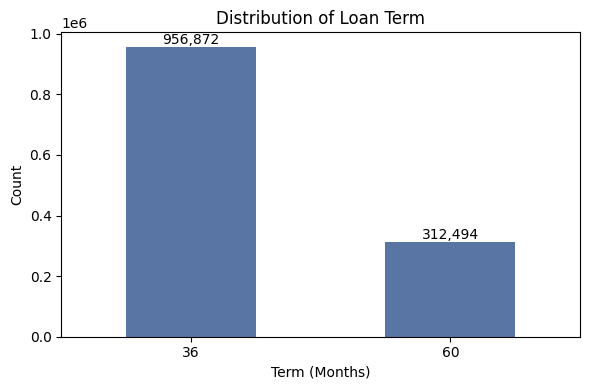

In [30]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="term_clean", data=loans_cleaned, width=0.5, palette=["#4C72B0"])  # blue
plt.title("Distribution of Loan Term")
plt.xlabel("Term (Months)")
plt.ylabel("Count")

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 4. Numerical features distribution

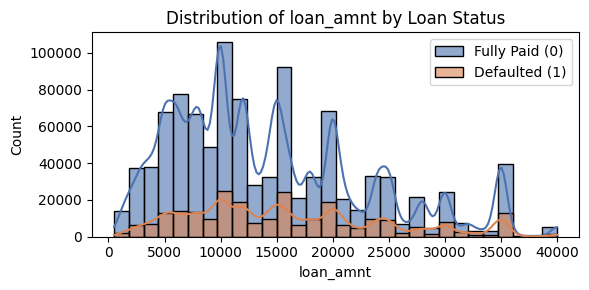

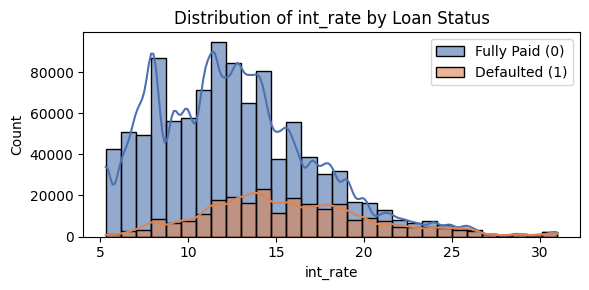

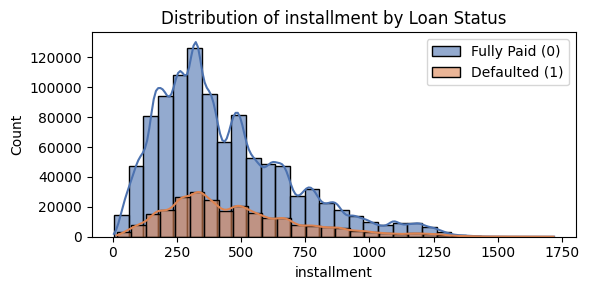

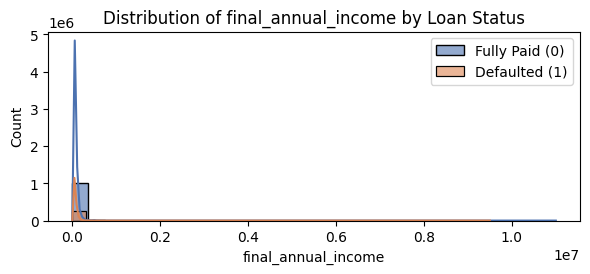

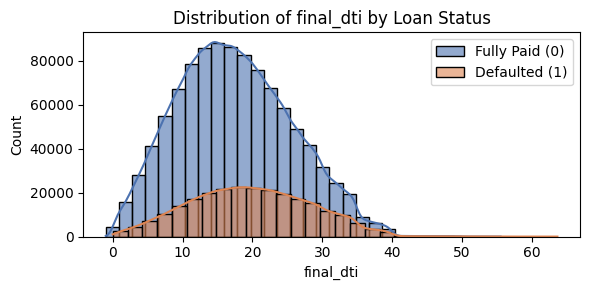

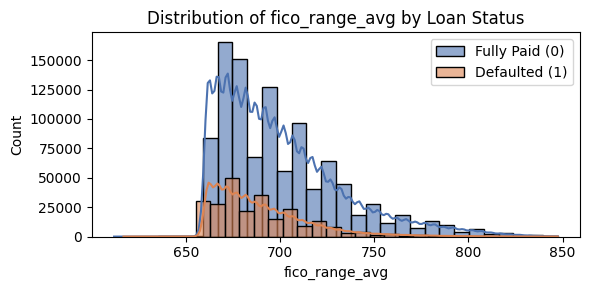

In [35]:
numerical_cols = ["loan_amnt", "int_rate", "installment", "final_annual_income", 
                  "final_dti", "fico_range_avg"]

for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    for status, label, color in zip([0, 1], ['Fully Paid (0)', 'Defaulted (1)'], ['#4C72B0', '#DD8452']):
        sns.histplot(
            data=loans_cleaned[loans_cleaned["target_loan_status"] == status],
            x=col,
            kde=True,
            bins=30,
            label=label,
            color=color,
            alpha=0.6
        )
    plt.title(f"Distribution of {col} by Loan Status")
    plt.xlabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 5. Target varuable vs numerical features - boxplots

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


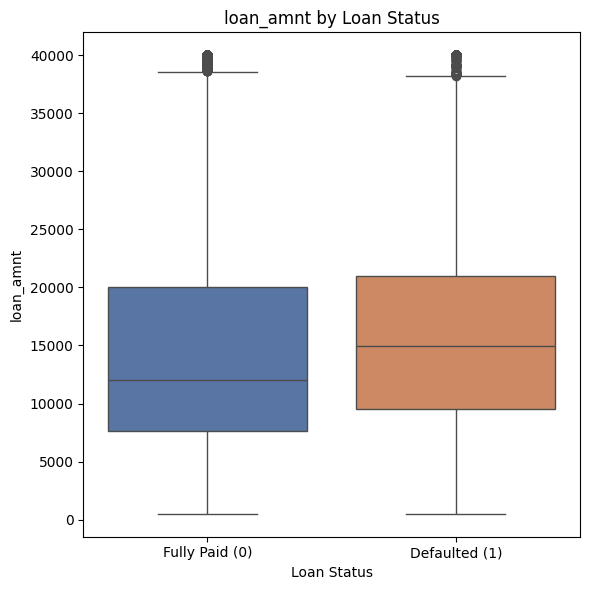

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


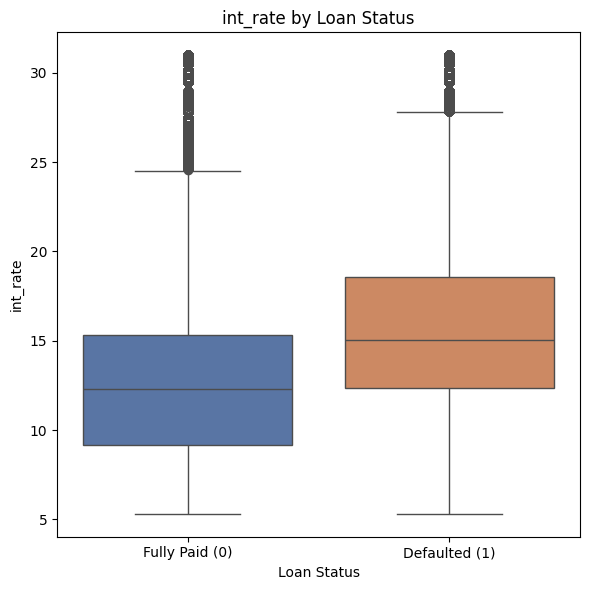

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


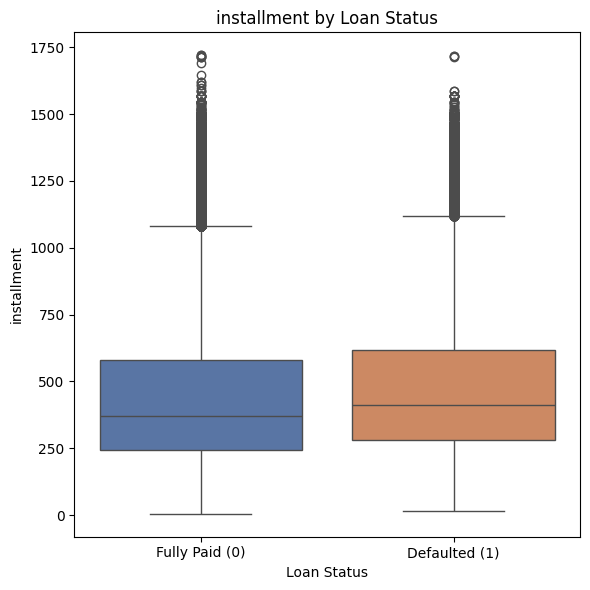

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


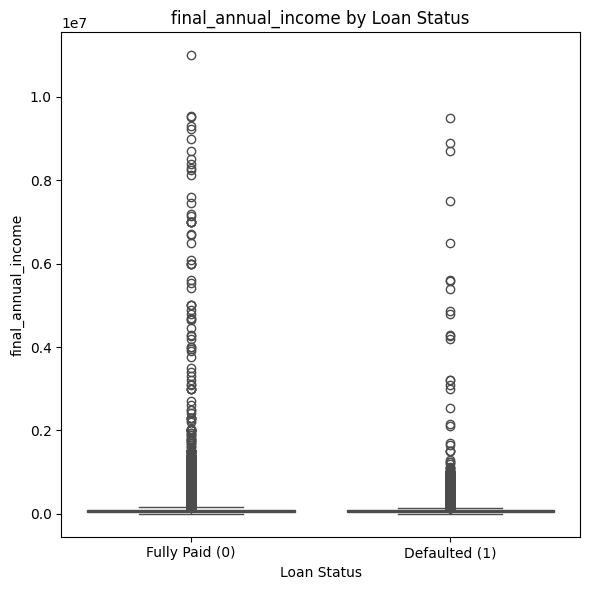

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


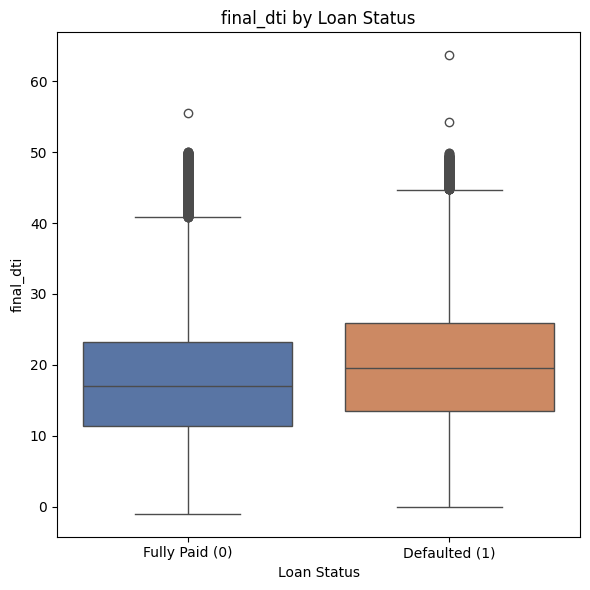

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\315103253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})


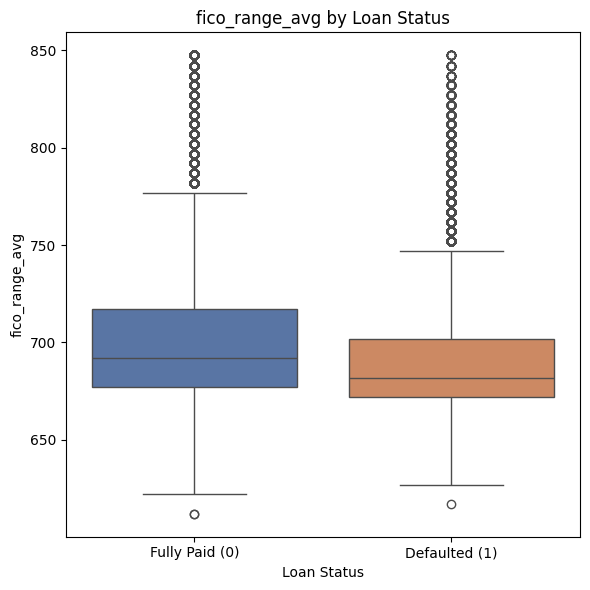

In [32]:
for col in numerical_cols:
    plt.figure(figsize=(6, 6))
    sns.boxplot(x="target_loan_status", y=col, data=loans_cleaned, palette={"0": "#4C72B0", "1": "#DD8452"})
    plt.title(f"{col} by Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(col)
    plt.xticks([0, 1], ['Fully Paid (0)', 'Defaulted (1)'])
    plt.tight_layout()
    plt.show()

### 6. Categorical feature breakdown by target variable

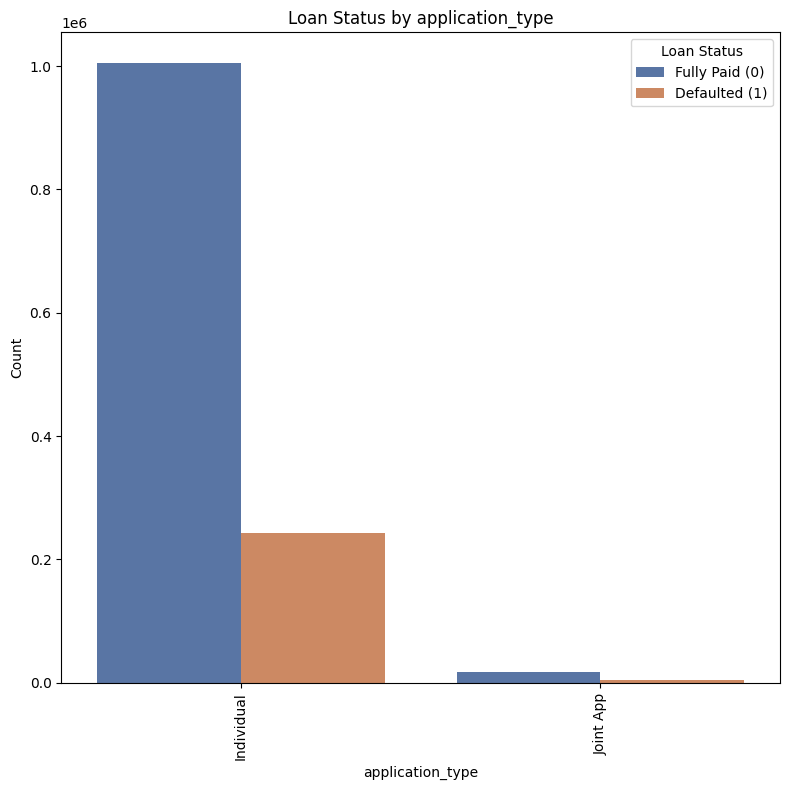

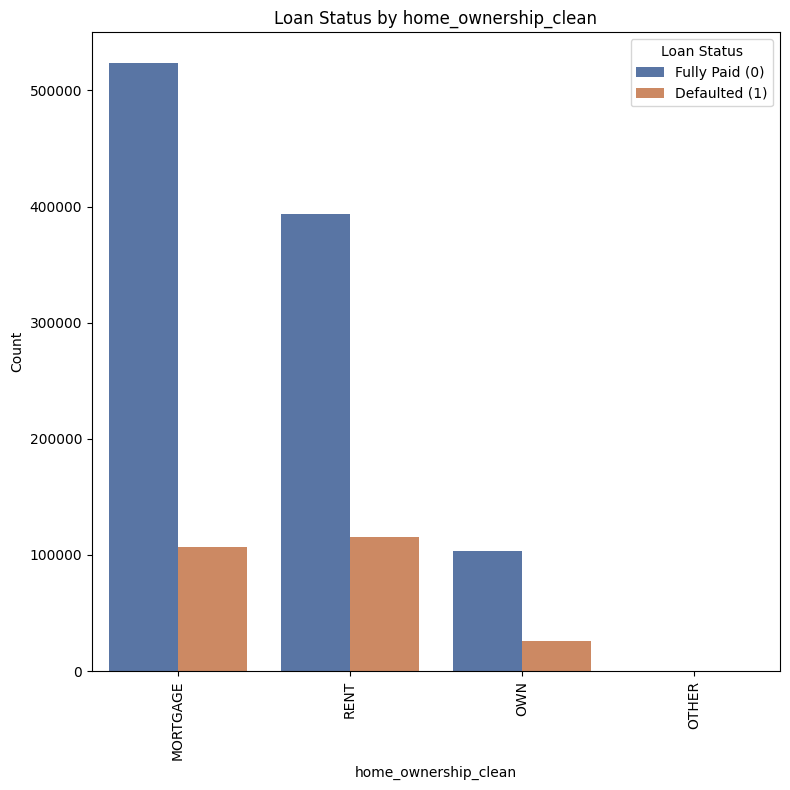

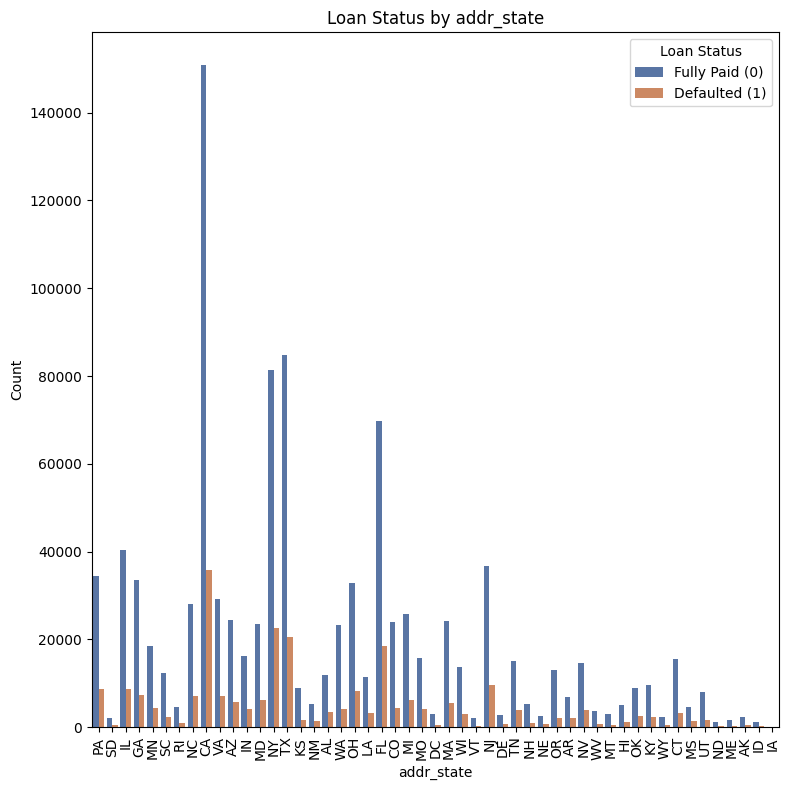

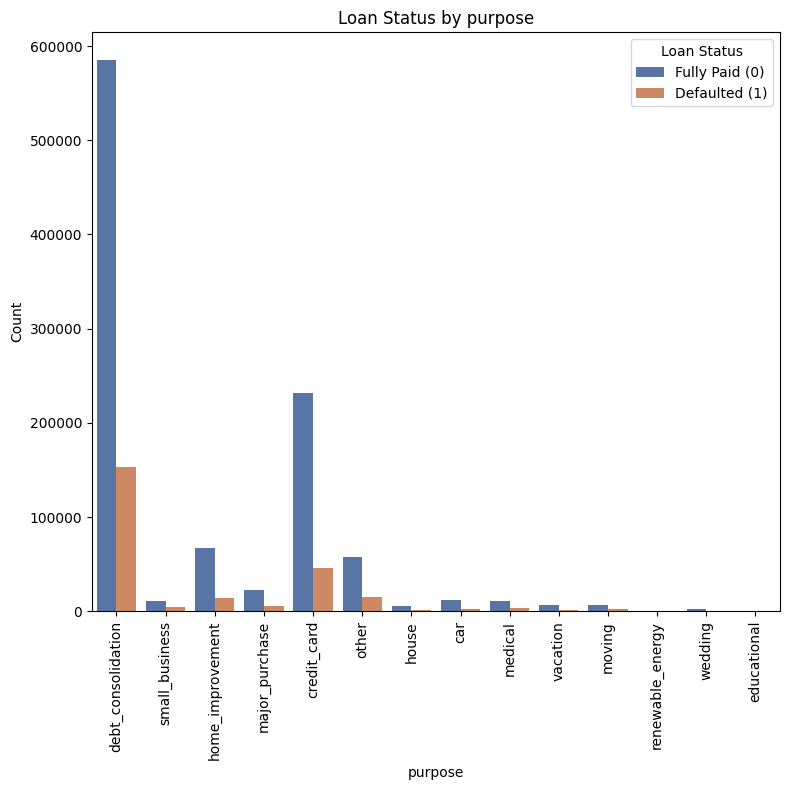

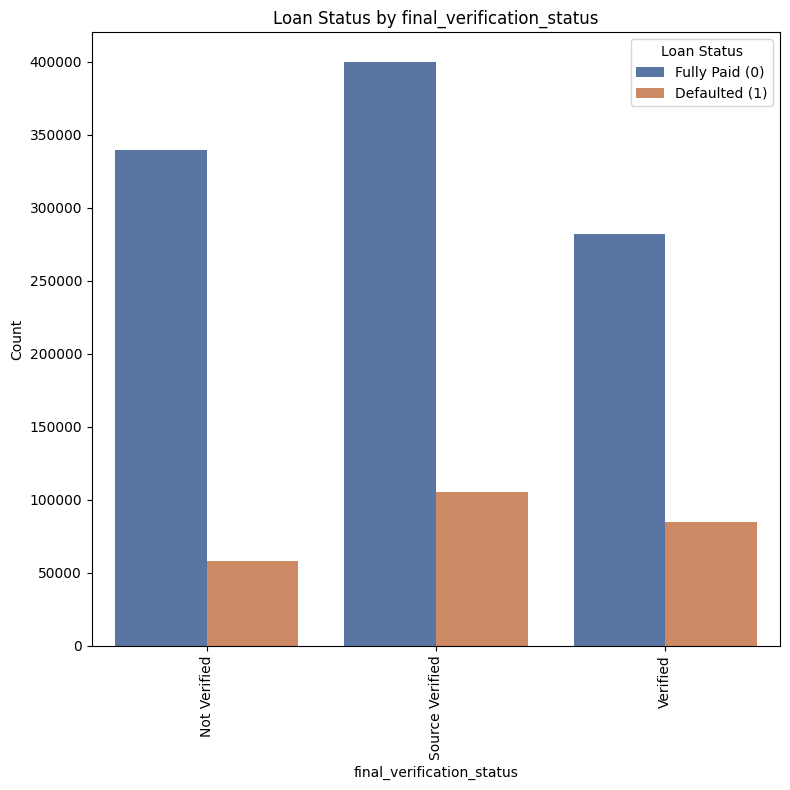

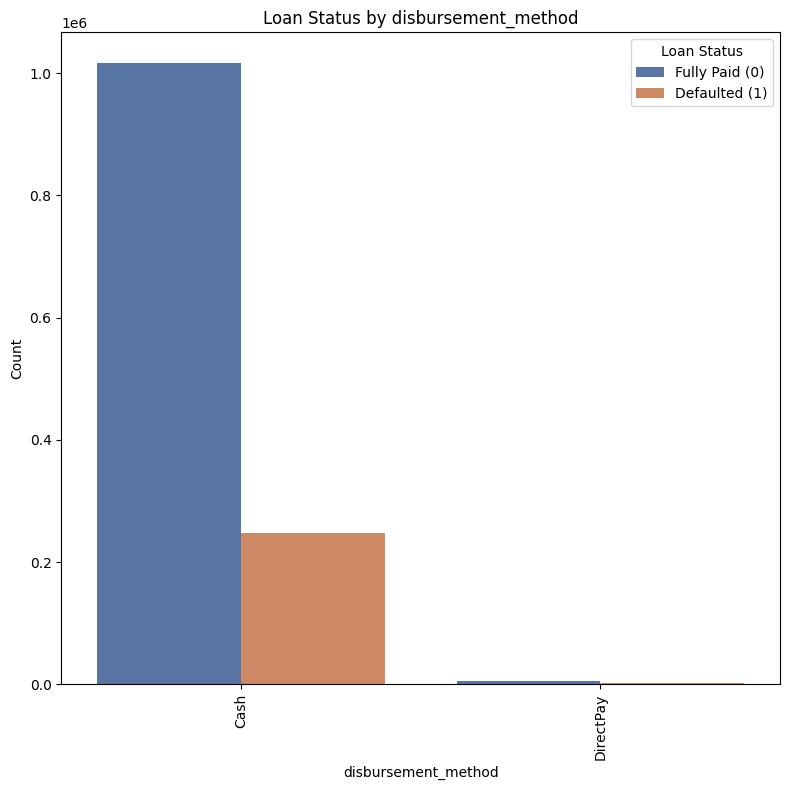

In [36]:
categorical_cols = ["application_type", "home_ownership_clean", "addr_state", 
                    "purpose", "final_verification_status", "disbursement_method"]

for col in categorical_cols:
    plt.figure(figsize=(8, 8))
    sns.countplot(
        x=col, 
        hue="target_loan_status", 
        data=loans_cleaned, 
        palette={0: "#4C72B0", 1: "#DD8452"}
    )
    plt.title(f"Loan Status by {col}")
    plt.xticks(rotation=90)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Loan Status", labels=['Fully Paid (0)', 'Defaulted (1)'])
    plt.tight_layout()
    plt.show()

### 7. Trend Over Time

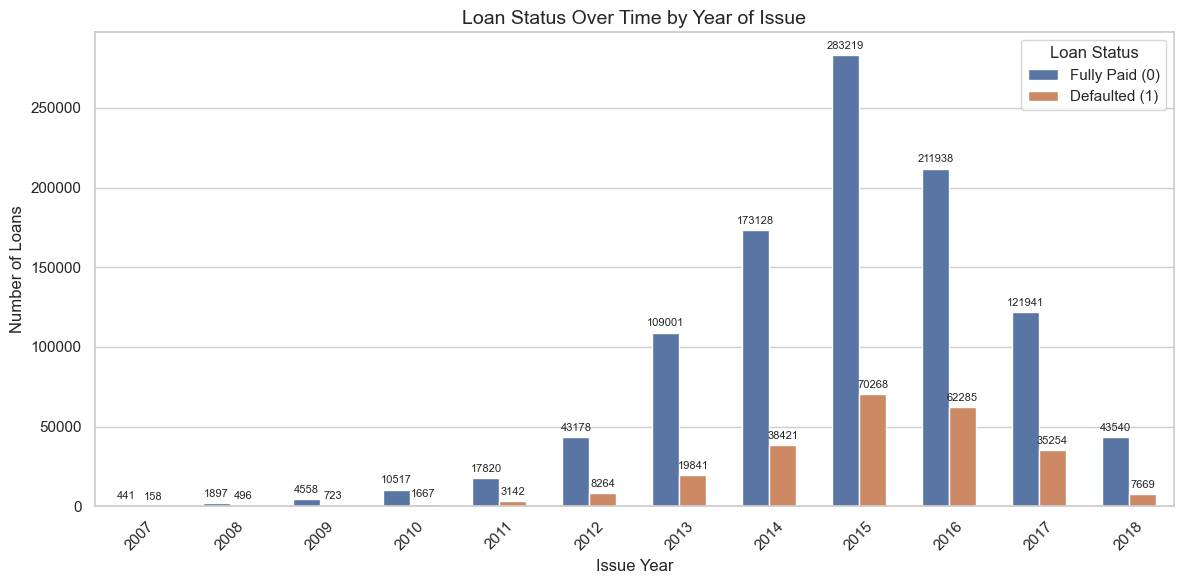

In [37]:
# Prepare year column
loans_cleaned["issue_year"] = loans_cleaned["issue_d"].dt.year

# Aggregate count per year and loan status
yearly_counts = loans_cleaned.groupby(["issue_year", "target_loan_status"]).size().reset_index(name="count")


# Set style and figure size
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the bar plot
bar_plot = sns.barplot(
    x='issue_year', 
    y='count', 
    hue='target_loan_status', 
    data=yearly_counts,
    palette={0: '#4C72B0', 1: '#DD8452'},
    width=0.6
)

# Add labels to each bar
for container in bar_plot.containers:
    bar_plot.bar_label(container, label_type='edge', fontsize=8, padding=3)

# Titles and axis labels
plt.title("Loan Status Over Time by Year of Issue", fontsize=14)
plt.xlabel("Issue Year")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)

# Get handles and labels from the plot and set custom legend labels
handles, _ = bar_plot.get_legend_handles_labels()
plt.legend(handles=handles, title='Loan Status', labels=['Fully Paid (0)', 'Defaulted (1)'])

# Final layout
plt.tight_layout()
plt.show()

### 8. Correlation heatmap - numerical predictors

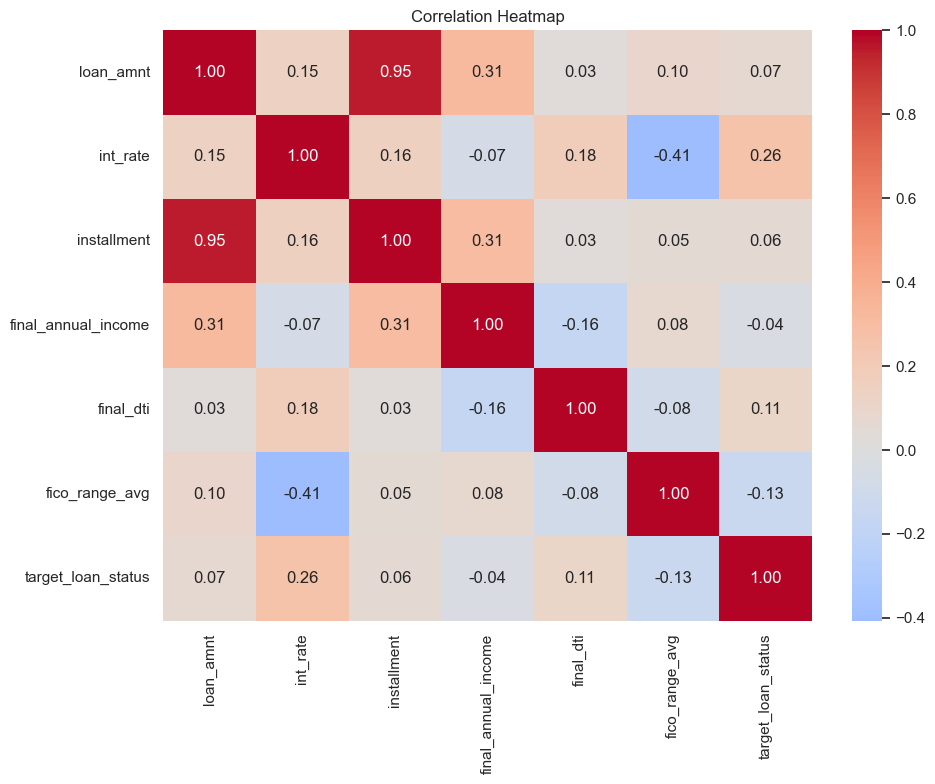

In [38]:
plt.figure(figsize=(10, 8))
corr = loans_cleaned[numerical_cols + ['target_loan_status']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 9. Heatmap of loan purpose by default rate

C:\Users\FED\AppData\Local\Temp\ipykernel_27828\3341577836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_defaults.values, y=purpose_defaults.index, palette="coolwarm")


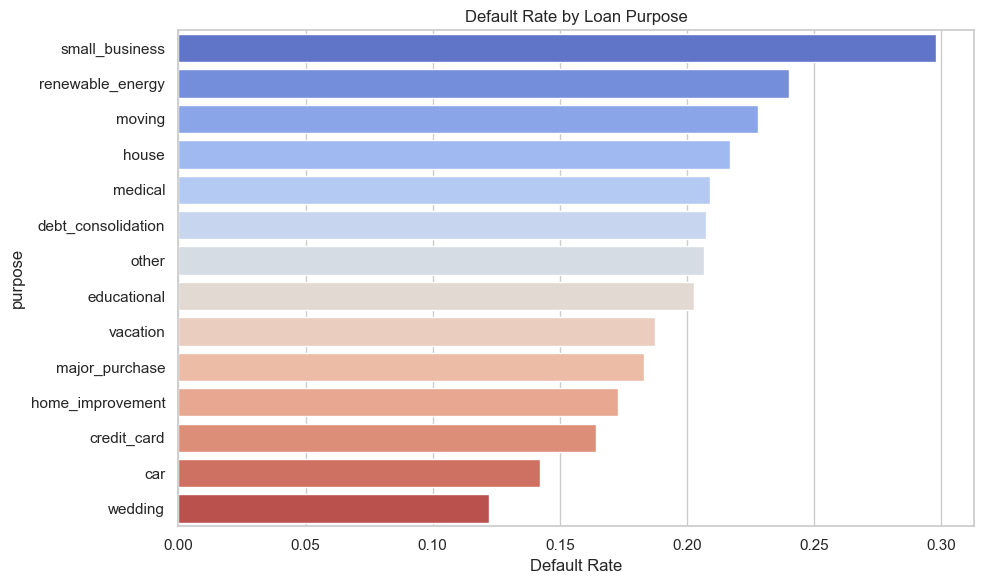

In [39]:
purpose_defaults = loans_cleaned.groupby("purpose")["target_loan_status"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=purpose_defaults.values, y=purpose_defaults.index, palette="coolwarm")
plt.xlabel("Default Rate")
plt.title("Default Rate by Loan Purpose")
plt.tight_layout()
plt.show()

## Model prediction

In [ ]:
# Install modeling libraries
install_and_import("scikit-learn", "sklearn")
install_and_import("xgboost")



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np

### Define features and target

In [41]:
# Drop unused or ID-related columns
loans_cleaned_model = loans_cleaned.drop(columns=["id", "issue_d"])


# Define target and features
X = loans_cleaned_model.drop(columns=["target_loan_status"])
y = loans_cleaned_model["target_loan_status"]


# Identify column types
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

### Processing pipeline

### Define transformations

In [42]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
numerical_transformer = StandardScaler()

### Combine preprocessing steps

In [43]:
preprocessor = ColumnTransformer(
transformers=[
("num", numerical_transformer, numerical_features),
("cat", categorical_transformer, categorical_features)
]
)

### Split the data with stratification to preserve class distribution

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)

### Fit transformation only on training data

In [45]:
# Fit transform only on training data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

### Helper function to evaluate models

In [ ]:
install_and_import("tabulate")

def evaluate_model(name, model, use_transformed=True):
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    X_eval = X_test_transformed if use_transformed else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    print(f"\n{name} Results")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_eval, y_test, cmap="Blues"
    )
    disp.ax_.set_title(f"{name} Confusion Matrix")
    disp.ax_.grid(False)
    plt.tight_layout()
    plt.show()

### Import for models

In [47]:
install_and_import("tqdm")
from tqdm import tqdm
import time  # just for demonstration purposes (optional)

## Baseline models on imbalanced dataset

### Logistic regression


Training Logistic Regression...

Logistic Regression Results
Confusion Matrix:
[[250797   4498]
 [ 57158   4889]]

Classification Report:
              precision    recall  f1-score   support

           0      0.814     0.982     0.891    255295
           1      0.521     0.079     0.137     62047

    accuracy                          0.806    317342
   macro avg      0.668     0.531     0.514    317342
weighted avg      0.757     0.806     0.743    317342

ROC AUC: 0.7098


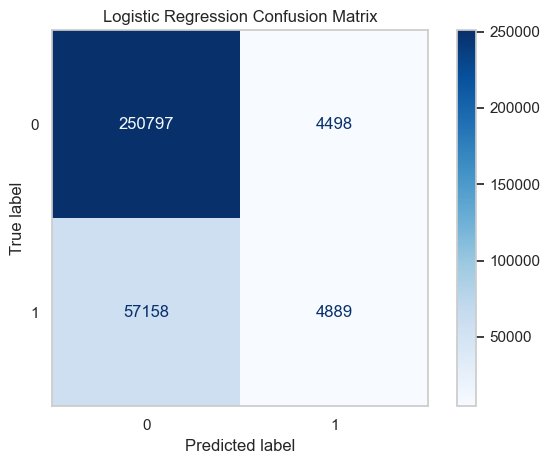

In [ ]:
print("\nTraining Logistic Regression...")
logreg = LogisticRegression()
logreg.fit(X_train_transformed, y_train)
evaluate_model("Logistic Regression", logreg)

### Random forest


Random Forest Results
Confusion Matrix:
[[250618   4677]
 [ 57238   4809]]

Classification Report:
              precision    recall  f1-score   support

           0      0.814     0.982     0.890    255295
           1      0.507     0.078     0.134     62047

    accuracy                          0.805    317342
   macro avg      0.661     0.530     0.512    317342
weighted avg      0.754     0.805     0.742    317342

ROC AUC: 0.6945


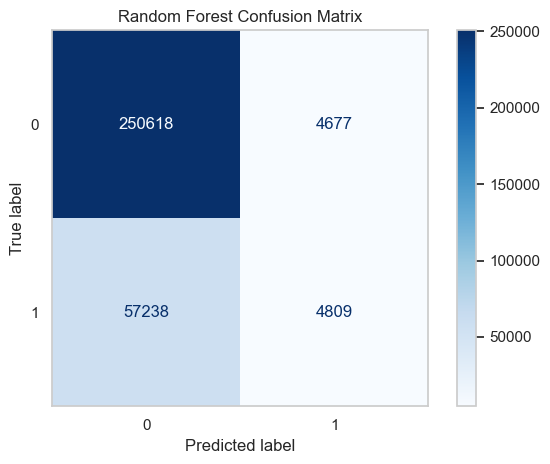

In [49]:
rf = RandomForestClassifier()
rf.fit(X_train_transformed, y_train)
evaluate_model("Random Forest", rf)

### XGBoost


XGBoost Results
Confusion Matrix:
[[251539   3756]
 [ 57437   4610]]

Classification Report:
              precision    recall  f1-score   support

           0      0.814     0.985     0.892    255295
           1      0.551     0.074     0.131     62047

    accuracy                          0.807    317342
   macro avg      0.683     0.530     0.511    317342
weighted avg      0.763     0.807     0.743    317342

ROC AUC: 0.7184


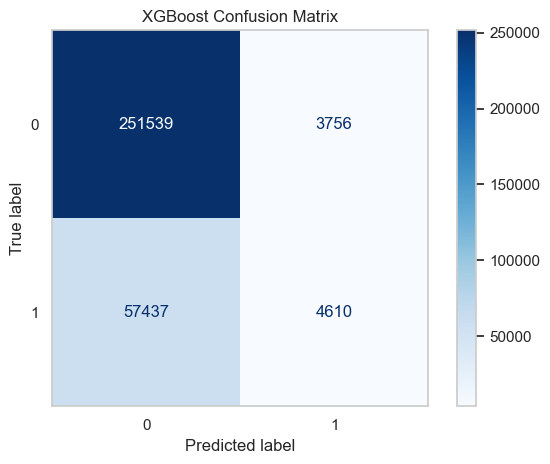

In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", verbosity=0)
xgb.fit(X_train_transformed, y_train)
evaluate_model("XGBoost", xgb)

## Baseline models on balanced dataset by doing undersampling

In [51]:
install_and_import("imbalanced-learn", "imblearn")

In [52]:
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling to the training set
undersampler = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train_transformed, y_train)

print("Class distribution after undersampling:")
print(pd.Series(y_train_balanced).value_counts())

Class distribution after undersampling:
target_loan_status
0    186141
1    186141
Name: count, dtype: int64


### Logistic regression balanced data

Training Logistic Regression on Balanced Data...

Logistic Regression (Balanced) Results
Confusion Matrix:
[[169910  85385]
 [ 22464  39583]]

Classification Report:
              precision    recall  f1-score   support

           0      0.883     0.666     0.759    255295
           1      0.317     0.638     0.423     62047

    accuracy                          0.660    317342
   macro avg      0.600     0.652     0.591    317342
weighted avg      0.772     0.660     0.693    317342

ROC AUC: 0.7099


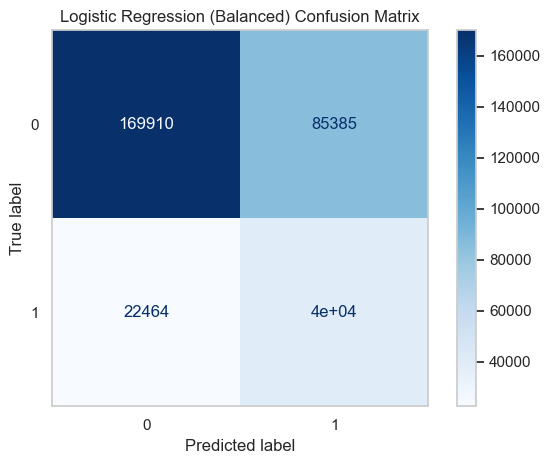

In [53]:
print("Training Logistic Regression on Balanced Data...")
logreg_bal = LogisticRegression(max_iter=1000)
logreg_bal.fit(X_train_balanced, y_train_balanced)
evaluate_model("Logistic Regression (Balanced)", logreg_bal)

### Random forest balanced data

Training Random Forest on Balanced Data...

Random Forest (Balanced) Results
Confusion Matrix:
[[163880  91415]
 [ 21740  40307]]

Classification Report:
              precision    recall  f1-score   support

           0      0.883     0.642     0.743    255295
           1      0.306     0.650     0.416     62047

    accuracy                          0.643    317342
   macro avg      0.594     0.646     0.580    317342
weighted avg      0.770     0.643     0.679    317342

ROC AUC: 0.7006


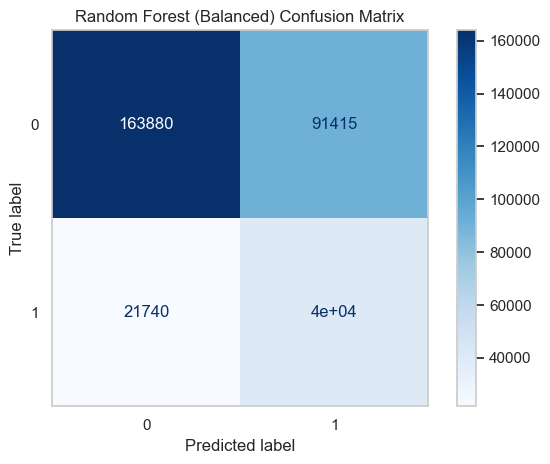

In [54]:
print("Training Random Forest on Balanced Data...")
rf_bal = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bal.fit(X_train_balanced, y_train_balanced)
evaluate_model("Random Forest (Balanced)", rf_bal)

### XGBoost balanced data

Training XGBoost on Balanced Data...

XGBoost (Balanced) Results
Confusion Matrix:
[[163130  92165]
 [ 20266  41781]]

Classification Report:
              precision    recall  f1-score   support

           0      0.889     0.639     0.744    255295
           1      0.312     0.673     0.426     62047

    accuracy                          0.646    317342
   macro avg      0.601     0.656     0.585    317342
weighted avg      0.777     0.646     0.682    317342

ROC AUC: 0.7163


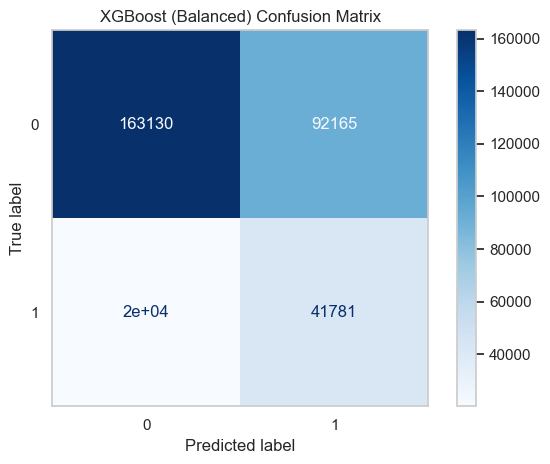

In [55]:
print("Training XGBoost on Balanced Data...")
xgb_bal = XGBClassifier(use_label_encoder=False, eval_metric="logloss", verbosity=0)
xgb_bal.fit(X_train_balanced, y_train_balanced)
evaluate_model("XGBoost (Balanced)", xgb_bal)

## Fine tuned models trained on balanced data using undersampling

### Logistic regression (tuned) trained on undersampled data

Training Logistic Regression (tuned)...

Logistic Regression (Tuned on Balanced) Results
Confusion Matrix:
[[169871  85424]
 [ 22470  39577]]

Classification Report:
              precision    recall  f1-score   support

           0      0.883     0.665     0.759    255295
           1      0.317     0.638     0.423     62047

    accuracy                          0.660    317342
   macro avg      0.600     0.652     0.591    317342
weighted avg      0.772     0.660     0.693    317342

ROC AUC: 0.7099


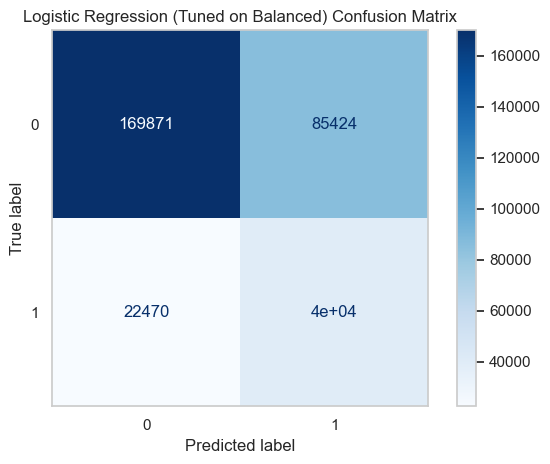

In [56]:
print("Training Logistic Regression (tuned)...")
# Fine-tuned logistic regression
logistic_tuned_balanced = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Fit on the balanced training data
logistic_tuned_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate on the full original test set
evaluate_model("Logistic Regression (Tuned on Balanced)", logistic_tuned_balanced)

### Random forest (tuned) trained on undersampled data

Training Random forest (tuned)...

Random Forest (Tuned on Balanced) Results
Confusion Matrix:
[[158185  97110]
 [ 19921  42126]]

Classification Report:
              precision    recall  f1-score   support

           0      0.888     0.620     0.730    255295
           1      0.303     0.679     0.419     62047

    accuracy                          0.631    317342
   macro avg      0.595     0.649     0.574    317342
weighted avg      0.774     0.631     0.669    317342

ROC AUC: 0.7065


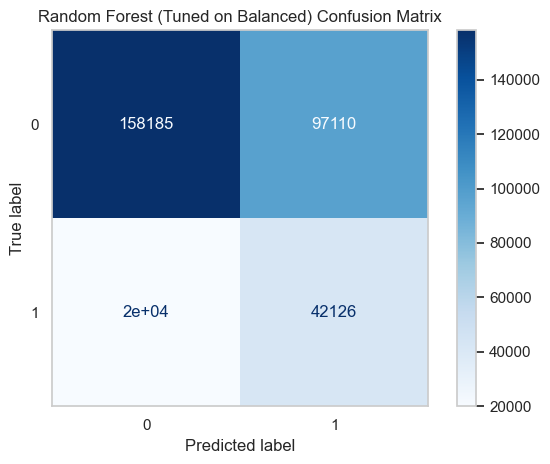

In [57]:
print("Training Random forest (tuned)...")

# Tuned Random Forest
rf_tuned_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# Train on balanced data
rf_tuned_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate
evaluate_model("Random Forest (Tuned on Balanced)", rf_tuned_balanced)

### XGBoost (tuned) trained on undersampled data

Training XGBoost (tuned)...


c:\Users\FED\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:13:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (Tuned on Balanced) Results
Confusion Matrix:
[[163330  91965]
 [ 20387  41660]]

Classification Report:
              precision    recall  f1-score   support

           0      0.889     0.640     0.744    255295
           1      0.312     0.671     0.426     62047

    accuracy                          0.646    317342
   macro avg      0.600     0.656     0.585    317342
weighted avg      0.776     0.646     0.682    317342

ROC AUC: 0.7159


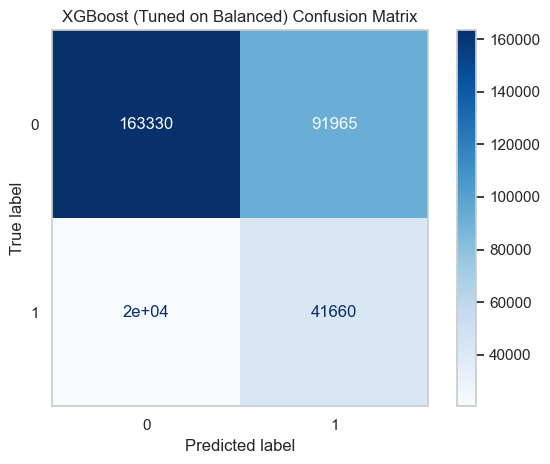

In [58]:
print("Training XGBoost (tuned)...")

# Tuned XGBoost
xgb_tuned_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train on balanced data
xgb_tuned_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate
evaluate_model("XGBoost (Tuned on Balanced)", xgb_tuned_balanced)

## Fine tuned models trained on balanced data using SMOTE

In [59]:
from imblearn.over_sampling import SMOTE

### Apply SMOTE

In [60]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
target_loan_status
0    765883
1    765883
Name: count, dtype: int64


### Logistic regression (tuned) trained on SMOTE data

Training Logistic Regression (Tuned) on SMOTE data...

Logistic Regression (Tuned SMOTE) Results
Confusion Matrix:
[[169407  85888]
 [ 22466  39581]]

Classification Report:
              precision    recall  f1-score   support

           0      0.883     0.664     0.758    255295
           1      0.315     0.638     0.422     62047

    accuracy                          0.659    317342
   macro avg      0.599     0.651     0.590    317342
weighted avg      0.772     0.659     0.692    317342

ROC AUC: 0.7084


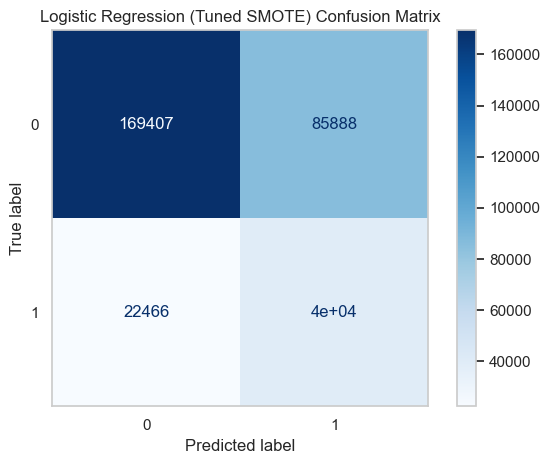

In [61]:
print("Training Logistic Regression (Tuned) on SMOTE data...")

logreg_smote = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
logreg_smote.fit(X_train_smote, y_train_smote)

evaluate_model("Logistic Regression (Tuned SMOTE)", logreg_smote)

### Random forest (tuned) trained on SMOTE data

Training Random Forest (Tuned) on SMOTE data...

Random Forest (Tuned SMOTE) Results
Confusion Matrix:
[[166548  88747]
 [ 22867  39180]]

Classification Report:
              precision    recall  f1-score   support

           0      0.879     0.652     0.749    255295
           1      0.306     0.631     0.412     62047

    accuracy                          0.648    317342
   macro avg      0.593     0.642     0.581    317342
weighted avg      0.767     0.648     0.683    317342

ROC AUC: 0.6987


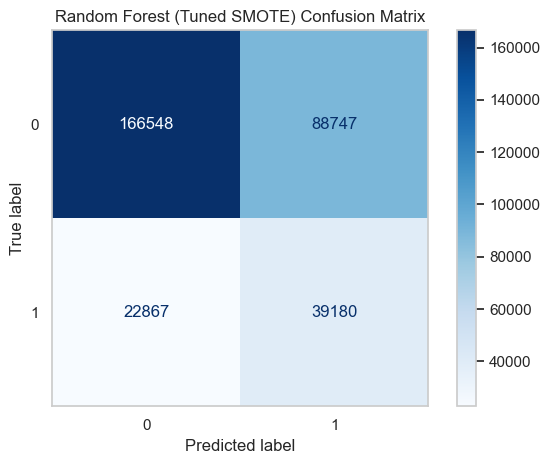

In [62]:
print("Training Random Forest (Tuned) on SMOTE data...")

rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)

evaluate_model("Random Forest (Tuned SMOTE)", rf_smote)

### XGBoost (tuned) trained on SMOTE data

Training XGBoost on SMOTE data...


c:\Users\FED\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (SMOTE) Results
Confusion Matrix:
[[229346  25949]
 [ 44116  17931]]

Classification Report:
              precision    recall  f1-score   support

           0      0.839     0.898     0.867    255295
           1      0.409     0.289     0.339     62047

    accuracy                          0.779    317342
   macro avg      0.624     0.594     0.603    317342
weighted avg      0.755     0.779     0.764    317342

ROC AUC: 0.7004


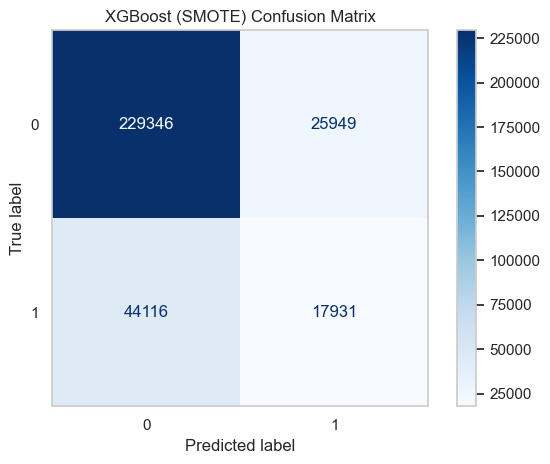

In [63]:
print("Training XGBoost on SMOTE data...")
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)

evaluate_model("XGBoost (SMOTE)", xgb_smote)